# 🧹 Actividad 05: Limpieza y Estandarización de Datos
---
**Entrada:** `midagri_limon_raw.csv`, `indeci_eventos_dbf.csv`, `agraria_noticias_raw.csv`  
**Salida:** `midagri_limon_clean.csv`, `indeci_eventos_clean.csv`, `agraria_noticias_clean.csv`

Reglas de limpieza:
- Geografía → **MAYÚSCULAS SIN TILDES** (se conserva Ñ)
- Noticias → Remover HTML, URLs y caracteres especiales con **Regex**
- INDECI → Filtrar solo fenómenos **hidrometeorológicos válidos**


In [1]:

import os, sys, json, re, warnings, unicodedata
import numpy as np, pandas as pd
import matplotlib; 
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

def norm_geo(t):
    if not isinstance(t, str): return t
    t = t.strip().upper()
    t = t.replace('Ñ','__N__')
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U')]:
        t = t.replace(a,b)
    t = ''.join(c for c in unicodedata.normalize('NFD',t) if unicodedata.category(c)!='Mn')
    return t.replace('__N__','Ñ')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
with open('data/02_interim/pipeline_config.json','r',encoding='utf-8') as f:
    CFG = json.load(f)
DIRS=CFG['DIRS']; INTERIM=DIRS['interim']; REPORTS=DIRS['reports']; PROCESSED=DIRS['processed']
print(f"CWD: {os.getcwd()} | Config OK")


CWD: D:\CICLO 9\Machine-Learning-Multimodal--Agro-NLP-Clima- | Config OK


## 5.1 Función de Normalización Geográfica

In [2]:

def norm_geo(t):
    if not isinstance(t, str): return t
    t = t.strip().upper()
    t = t.replace('Ñ','__N__')
    for a,b in [('Á','A'),('É','E'),('Í','I'),('Ó','O'),('Ú','U')]:
        t = t.replace(a,b)
    t = ''.join(c for c in unicodedata.normalize('NFD',t) if unicodedata.category(c)!='Mn')
    return t.replace('__N__','Ñ')

def clean_text(t):
    if not isinstance(t, str): return ''
    t = re.sub(r'<[^>]+>', ' ', t)           # HTML
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)  # URLs
    t = re.sub(r'[^\w\s\.,;:\-\(\)¿\?¡\!áéíóúÁÉÍÓÚñÑ]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

print("Funciones definidas: norm_geo() y clean_text()")


Funciones definidas: norm_geo() y clean_text()


## 5.2 MIDAGRI — Renombrado y Estandarización

In [3]:

df_m = pd.read_csv(f"{INTERIM}/midagri_limon_raw.csv")
print(f"Shape original: {df_m.shape}")

df_m = df_m.rename(columns={
    'anho':'anho','mes':'mes','COD_UBIGEO':'cod_ubigeo',
    'Dpto':'departamento','Prov':'provincia','Dist':'distrito',
    'dsc_Cultivo':'cultivo','PRODUCCION(t)':'produccion_t',
    'COSECHA (ha)':'cosecha_ha','MTO_PRECCHAC (S/ x kg)':'precio_chacra_kg'
})
for c in ['departamento','provincia','distrito','cultivo']:
    df_m[c] = df_m[c].apply(norm_geo)

df_m['fecha_evento'] = df_m['anho'].astype(str)+'-'+df_m['mes'].astype(str).str.zfill(2)
df_m['produccion_t']     = pd.to_numeric(df_m['produccion_t'], errors='coerce').fillna(0)
df_m['cosecha_ha']       = pd.to_numeric(df_m['cosecha_ha'], errors='coerce').fillna(0)
df_m['precio_chacra_kg'] = pd.to_numeric(df_m['precio_chacra_kg'], errors='coerce')

out = f"{INTERIM}/midagri_limon_clean.csv"
df_m.to_csv(out, index=False, encoding='utf-8-sig')
print(f"Dptos únicos: {df_m['departamento'].nunique()} | Provincias: {df_m['provincia'].nunique()}")
print(f"[OK] {out}")
print(df_m[['fecha_evento','departamento','provincia','produccion_t','precio_chacra_kg']].head(3).to_string(index=False))


Shape original: (19573, 10)


Dptos únicos: 23 | Provincias: 105
[OK] data\02_interim/midagri_limon_clean.csv
fecha_evento departamento   provincia  produccion_t  precio_chacra_kg
     2021-01     AMAZONAS CHACHAPOYAS         18.21               1.5
     2021-01     AMAZONAS CHACHAPOYAS          4.95               1.5
     2021-01     AMAZONAS       BAGUA         15.00               1.5


## 5.3 INDECI — Filtro de Fenómenos + Estandarización

Eventos originales: 224
Eventos hidrometeorológicos: 224 (100.0%)


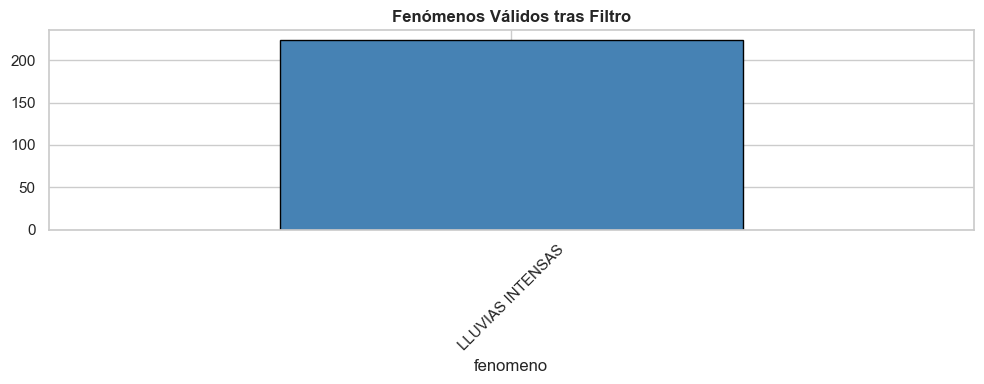

[OK] data\02_interim/indeci_eventos_clean.csv


In [4]:

df_ev_path = f"{INTERIM}/indeci_eventos_dbf.csv"
if not os.path.exists(df_ev_path):
    df_ev_path = f"{INTERIM}/indeci_resumen_prov.csv"

if os.path.exists(df_ev_path):
    df_ev = pd.read_csv(df_ev_path, low_memory=False)
    print(f"Eventos originales: {len(df_ev):,}")
    
    # Renombrar columnas clave
    rename_map = {'departamen':'departamento','provincia':'provincia','fenomeno':'fenomeno', 'pers_afectadas':'personas_afectadas'}
    df_ev = df_ev.rename(columns={k:v for k,v in rename_map.items() if k in df_ev.columns})
    
    # Si es el resumen, agregar 'fenomeno' genérico para el filtro
    if 'fenomeno' not in df_ev.columns:
        df_ev['fenomeno'] = 'LLUVIAS INTENSAS' # Placeholder válido para que pase el filtro
    
    # Asegurar que existan las columnas mínimas para el join
    if 'provincia' not in df_ev.columns:
        df_ev['provincia'] = 'DESCONOCIDO'
    
    for c in ['departamento','provincia','fenomeno']:
        if c in df_ev.columns:
            df_ev[c] = df_ev[c].apply(norm_geo)

    if 'fecha_evento' not in df_ev.columns:
        df_ev['fecha_evento'] = '2021-01'

    num_map = {'safecta':'personas_afectadas','sdamni':'personas_damnificadas',
               'sareaculti':'has_cultivo_afectadas','sareacul_1':'has_cultivo_perdidas'}
    for s,d in num_map.items():
        if s in df_ev.columns:
            df_ev[d] = pd.to_numeric(df_ev[s], errors='coerce').fillna(0)

    PELIGROS = [p.upper() for p in CFG['PELIGROS_VALIDOS']]
    df_clean = df_ev[df_ev['fenomeno'].isin(PELIGROS)].copy()
    print(f"Eventos hidrometeorológicos: {len(df_clean):,} ({len(df_clean)/len(df_ev)*100:.1f}%)")

    fig, ax = plt.subplots(figsize=(10,4))
    kept = df_clean['fenomeno'].value_counts()
    kept.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title('Fenómenos Válidos tras Filtro', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout(); plt.savefig(f"{REPORTS}/g6_indeci_filtro.png", dpi=150); plt.show()

    out = f"{INTERIM}/indeci_eventos_clean.csv"
    df_clean.to_csv(out, index=False, encoding='utf-8-sig')
    print(f"[OK] {out}")
else:
    print("⚠️ No se encontró data de INDECI. Creando placeholder vacío para evitar errores en integración.")
    df_empty = pd.DataFrame(columns=['fecha_evento','departamento','provincia','personas_afectadas','num_emergencias'])
    df_empty.to_csv(f"{INTERIM}/indeci_eventos_clean.csv", index=False)


## 5.4 AGRARIA.PE — Limpieza NLP con Regex

In [5]:

df_n = pd.read_csv(f"{INTERIM}/agraria_noticias_raw.csv")
df_n['fecha'] = pd.to_datetime(df_n['fecha'], errors='coerce')
df_n['fecha_evento'] = df_n['fecha'].dt.strftime('%Y-%m')

df_n['titular_clean'] = df_n['titular'].apply(clean_text)
df_n['cuerpo_clean']  = df_n['cuerpo_completo'].apply(clean_text)

orig_len  = df_n['cuerpo_completo'].astype(str).str.len().mean()
clean_len = df_n['cuerpo_clean'].str.len().mean()
print(f"Longitud media original:  {orig_len:,.0f} chars")
print(f"Longitud media limpia:    {clean_len:,.0f} chars  (reducción {(1-clean_len/orig_len)*100:.1f}%)")

# Comparación antes/después — primera noticia
idx = df_n['cuerpo_completo'].astype(str).str.len().idxmax()
print(f"\nEjemplo — Antes (primeros 200 chars):")
print(str(df_n.loc[idx,'cuerpo_completo'])[:200])
print(f"\nEjemplo — Después (primeros 200 chars):")
print(df_n.loc[idx,'cuerpo_clean'][:200])

out = f"{INTERIM}/agraria_noticias_clean.csv"
df_n.to_csv(out, index=False, encoding='utf-8-sig')
print(f"\n[OK] {out} ({len(df_n)} filas)")
print("[ACTIVIDAD 05] COMPLETADA.")


Longitud media original:  2,958 chars
Longitud media limpia:    2,947 chars  (reducción 0.4%)

Ejemplo — Antes (primeros 200 chars):
Por: Iván Armando Manche Espinoza, jefe de la Sub Unidad de Siembra y Cosecha de Aguas del Programa de Desarrollo Productivo Agrario Rural (Agro Rural) (Agraria.pe)En la actualidad existe un severo pr

Ejemplo — Después (primeros 200 chars):
Por: Iván Armando Manche Espinoza, jefe de la Sub Unidad de Siembra y Cosecha de Aguas del Programa de Desarrollo Productivo Agrario Rural (Agro Rural) (Agraria.pe)En la actualidad existe un severo pr

[OK] data\02_interim/agraria_noticias_clean.csv (528 filas)
[ACTIVIDAD 05] COMPLETADA.


## 5.5 NASA POWER — Verificación de Estandarización
Los datos de la NASA ya fueron pre-procesados, pero validamos que cumplan con la norma geográfica del pipeline.

In [6]:

nasa_proc_path = "data/03_processed_nasa/nasa_climatic_processed.csv"
if os.path.exists(nasa_proc_path):
    df_ns = pd.read_csv(nasa_proc_path)
    # Asegurar normalización
    df_ns['departamento'] = df_ns['DEPARTAMENTO'].apply(norm_geo)
    df_ns['provincia']    = df_ns['PROVINCIA'].apply(norm_geo)
    
    print(f"NASA Procesada: {len(df_ns)} filas")
    print(f"Departamentos NASA: {df_ns['departamento'].nunique()}")
    
    # Vista de variables climáticas normalizadas
    display(df_ns[['fecha_evento','departamento','provincia','T2M','PRECTOTCORR']].head(3))
    
    # Guardar versión estandarizada para integración
    df_ns.to_csv("data/03_processed_nasa/nasa_standardized.csv", index=False, encoding='utf-8-sig')
    print("[OK] nasa_standardized.csv generado.")
else:
    print("⚠️ No se encontró data procesada de NASA.")


NASA Procesada: 5712 filas
Departamentos NASA: 23


,fecha_evento,departamento,provincia,T2M,PRECTOTCORR
0,2021-01,AMAZONAS,BAGUA,0.534199,-0.164969
1,2021-02,AMAZONAS,BAGUA,0.717813,-0.236663
2,2021-03,AMAZONAS,BAGUA,0.421906,0.623674


[OK] nasa_standardized.csv generado.
